In [ ]:
# %load_ext watermark
# %watermark -a "Paul A. Wambo" -v -p Bio,matplotlib,numpy,pandas,pyMIBiG,seaborn,selfies,sklearn,transformers,torch,umap

In [ ]:
import os

import torch

import numpy as np
import pandas as pd
import seaborn as sns
# import selfies as sf
import matplotlib.pyplot as plt

# from Bio import SeqIO
from transformers import AutoTokenizer, AutoModel
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from umap import UMAP

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
datapath = "/content/drive/MyDrive/criblage_biosciences/data/output"

In [ ]:
df = pd.read_parquet(os.path.join(datapath, "mibig4_sequence_data.parquet"))
df.head()

In [ ]:
model_name = "facebook/esm2_t12_35M_UR50D"  # "facebook/esm2_t33_650M_UR50D"

tokenizer = AutoTokenizer.from_pretrained(model_name, do_lower_case=False)
model = AutoModel.from_pretrained(model_name)

In [ ]:
# nuc_tokenizer = AutoTokenizer.from_pretrained("InstaDeepAI/nucleotide-transformer-v2-50m-3mer-multi-species", trust_remote_code=True)
# nuc_model = AutoModelForMaskedLM.from_pretrained("InstaDeepAI/nucleotide-transformer-v2-50m-3mer-multi-species", trust_remote_code=True)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

In [ ]:
model.to(device)

In [ ]:
proteins = df['protein_sequence']

In [ ]:
MAX_LEN_PROT = 1024   # typical max for ESM2 small models
STRIDE = 128          # overlap for chunking

def chunk_sequence(seq, size=1022):
    for i in range(0, len(seq), size):
        yield seq[i:i+size]

In [ ]:
from tqdm import tqdm

def process_chunk(df_chunk, chunk_id):
    embeddings = []

    for i, row in tqdm(df_chunk.iterrows(), total=len(df_chunk), desc=f"Chunk {chunk_id}"):
        seq = row["protein_sequence"]
        chunk_vecs = []

        for chunk in chunk_sequence(seq):        # non-overlapping
            tokens = tokenizer(
                chunk,
                return_tensors="pt",
                truncation=True,
                max_length=MAX_LEN_PROT
            )
            tokens = {k: v.to(device) for k, v in tokens.items()}

            with torch.no_grad():
                out = model(**tokens)

                # CLS token embedding
                vec = out.last_hidden_state[:, 0, :].squeeze(0)

                # normalize
                vec = vec / vec.norm(p=2)

                chunk_vecs.append(vec.cpu())

        # === average chunk embeddings ===
        final_vec = torch.stack(chunk_vecs).mean(dim=0).numpy()

        embeddings.append(final_vec)

    df_chunk = df_chunk.copy()
    df_chunk["embeddings"] = embeddings

    save_path = os.path.join(datapath, f"chunk_{chunk_id}_embeddings_650M_v2.pkl")
    df_chunk.to_pickle(save_path)

    return save_path


In [ ]:
import math

num_chunks = 10
chunk_size = math.ceil(len(df) / num_chunks)

df_chunks = [
    df.iloc[i:i+chunk_size]
    for i in range(0, len(df), chunk_size)
]

In [ ]:
saved_paths = []

for chunk_id, df_chunk in enumerate(df_chunks):
    print(f"Processing chunk {chunk_id}...")
    path = process_chunk(df_chunk, chunk_id)
    # path = os.path.join(SAVE_DIR, f"bgc_chunk_{chunk_id}.pkl")
    saved_paths.append(path)


In [ ]:
saved_paths = [os.path.join(datapath, x) for x in os.listdir(datapath) if '35M' in x and x.endswith('.pkl')]

In [ ]:
import pickle as pkl

_df = []

for _, path in enumerate(saved_paths):
    with open(path, "rb") as f:
        _datum = pkl.load(f)
        _df.append(_datum)

df_embeddings = pd.concat(_df, ignore_index=True)
df_embeddings.head()

,bgc_id,protein_name,protein_id,protein_sequence,dna_sequence,embeddings,sequence,Biosynthetic Class,bgc_sequence
0,BGC0000001,orfP,AEK75490.1,MTELDRAFDAVPAPIYTHHERHGETVHRSAPESIRRELAALQVRAG...,GTGACCGAGCTCGACCGGGCCTTCGACGCCGTACCGGCCCCGATCT...,"[[tensor(0.2849), tensor(0.0568), tensor(-0.03...",NaN,NaN,NaN
1,BGC0000001,None,AEK75491.1,MKPPASSVCPVDTSKMGNRSSPARYGRRPRKRCVELSETNLEFVHV...,GTGAAGCCGCCGGCCAGCTCTGTCTGCCCGGTGGACACCTCGAAGA...,"[[tensor(0.1528), tensor(-0.0032), tensor(0.20...",NaN,NaN,NaN
2,BGC0000001,abyR,AEK75492.1,MLGALRIADPAPRTITAPKVETLFATLLIRANHTVTTDELIAELWG...,TTGCTCGGAGCATTGCGGATCGCCGATCCCGCACCTCGCACGATTA...,"[[tensor(0.1949), tensor(0.0387), tensor(0.077...",NaN,NaN,NaN
3,BGC0000001,abyX,AEK75493.1,MTDVQLPAFPMTRTCPHQPPEGYAALRENGPLAQVRLVGDRTAWVV...,ATGACCGACGTCCAGCTGCCCGCGTTCCCGATGACCCGCACCTGTC...,"[[tensor(0.1594), tensor(0.0027), tensor(-0.01...",NaN,NaN,NaN
4,BGC0000001,abyH,AEK75494.1,MRDTAEHRIGTSGRHTPQAQATPADRLSQALARARSGRGGVVELVG...,GTGCGCGACACGGCAGAGCATCGGATCGGCACATCCGGGCGTCACA...,"[[tensor(0.2322), tensor(-0.0312), tensor(-0.0...",NaN,NaN,NaN


In [ ]:
def unwrap_single(vec):
    # If it's [tensor], return tensor
    if isinstance(vec, list) and len(vec) == 1:
        return vec[0].cpu().numpy()
    # If it's a list with multiple vectors, average them
    if isinstance(vec, list) and len(vec) > 1:
        arr = torch.stack(vec).mean(0)
        return arr.cpu().numpy()
    # Already a tensor
    if torch.is_tensor(vec):
        return vec.cpu().numpy()
    # Otherwise, convert as usual
    return np.array(vec)

In [ ]:
df_embeddings['embeddings_fixed'] = df_embeddings['embeddings'].apply(unwrap_single)

In [ ]:
df_embeddings['embeddings_fixed'].apply(lambda x: np.array(x).shape).value_counts()

,count
embeddings_fixed,
"(480,)",50571


In [ ]:
# df_embeddings.to_parquet(os.path.join(datapath, "mibig4_with_embeddings_esm2_650M_v2.parquet"))

In [ ]:
_df = df_embeddings.copy()

In [ ]:
def normalize(v):
    norm = np.linalg.norm(v)
    if norm == 0:
        return v  # leave zero-vectors unchanged
    return v / norm


In [ ]:
_df['embeddings_normalized'] = _df['embeddings_fixed'].apply(normalize)
# _df['nucleotide_embedding_normalized'] = _df['nucleotide_embedding'].apply(normalize)

In [ ]:
annotation_df = pd.read_parquet(os.path.join(datapath, "mibig_proteins_labels_v2.parquet"))
annotation_df.head()

,protein_id,Protein_Name,np_labels,ec_labels
0,AEK75490.1,protein methyltransferase,Tailoring Enzyme,EC Transferase
1,AEK75491.1,putative hydrolase,Other,EC Hydrolase
2,AEK75492.1,pathway-specific SARP activator,Other,EC Unknown
3,AEK75493.1,cytochrome P450,Other,EC Unknown
4,AEK75494.1,LuxR family transcriptional regulator,Regulator,EC Unknown


In [ ]:
def run_pca(X, n_components=2):
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(X)
    return X_pca

In [ ]:
def run_umap(X, n_neighbors=15):
    umap_model = UMAP(random_state=42, metric='cosine', low_memory=True,
                      densmap=True, n_neighbors=n_neighbors)
    X_umap = umap_model.fit_transform(X)
    return X_umap

In [ ]:
_df = _df.drop_duplicates('protein_id')
annotation_df = annotation_df.drop_duplicates('protein_id')

In [ ]:
df_merged = _df.merge(annotation_df, on='protein_id', how='inner')
df_merged.columns

Index(['bgc_id', 'protein_name', 'protein_id', 'protein_sequence',
       'dna_sequence', 'embeddings', 'sequence', 'Biosynthetic Class',
       'bgc_sequence', 'embeddings_fixed', 'embeddings_normalized',
       'Protein_Name', 'np_labels', 'ec_labels'],
      dtype='object')

In [ ]:
df_merged.shape

(46349, 14)

In [ ]:
def remove_exact_sequence_duplicates(df):
    before = len(df)
    df = df.drop_duplicates(subset=["protein_sequence"])
    after = len(df)
    print(f"Exact duplicates removed: {before - after}")
    return df

In [ ]:
df_merged = remove_exact_sequence_duplicates(df_merged)

Exact duplicates removed: 978


In [ ]:
df_merged.shape

(45371, 14)

In [ ]:
X = np.vstack(df_merged['embeddings_normalized'])
# X_pca = run_pca(X)

In [ ]:
X_merged = run_umap(X)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:
projected_subset = pd.DataFrame({
    'UMAP_1': X_merged[:, 0],
    'UMAP_2': X_merged[:, 1],
    'name': df_merged['Protein_Name'],
    'enzyme_class': df_merged['ec_labels'],
    'np_class': df_merged['np_labels'],
})
#

In [ ]:
projected_subset.to_csv(os.path.join(datapath,
                                     "umap_proteins_embeddings_esm2_35M_v3.csv"),
                        index=False)

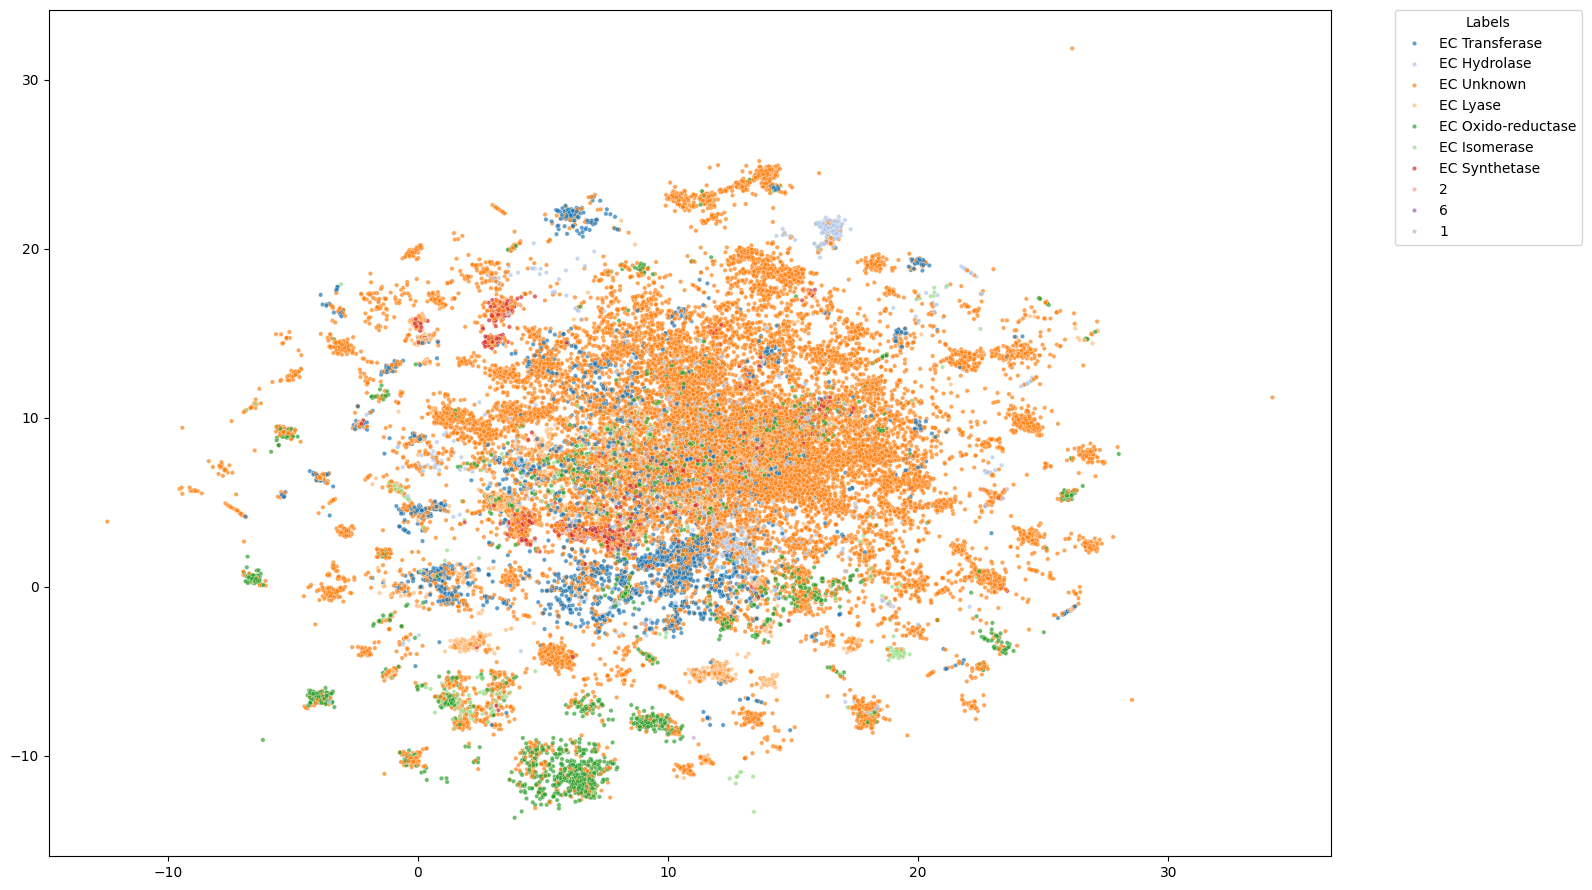

In [ ]:
plt.figure(figsize=(16, 9))

ax = sns.scatterplot(
    x=X_merged[:, 0],
    y=X_merged[:, 1],
    hue=df_merged['ec_labels'],
    palette='tab20',
    s=10,
    alpha=0.7
)

# Move legend outside
ax.legend(
    title="Labels",
    bbox_to_anchor=(1.05, 1),   # x-offset, y-offset
    loc='upper left',
    borderaxespad=0
)

plt.tight_layout()
plt.show()

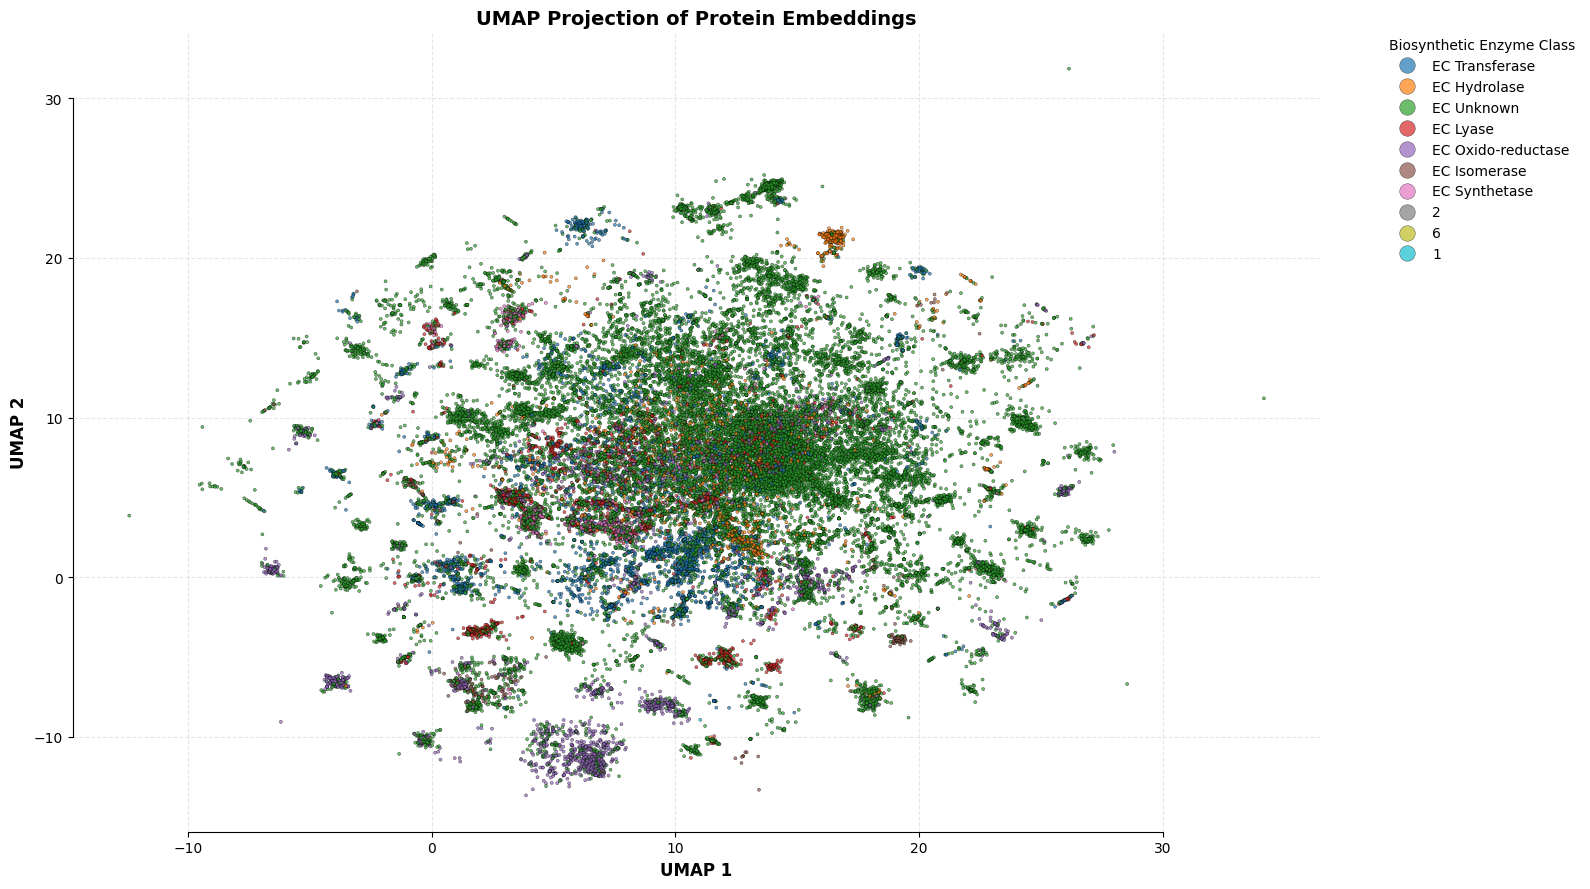

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use a colorblind-friendly palette
palette = sns.color_palette("tab10", n_colors=projected_subset['enzyme_class'].nunique())

plt.figure(figsize=(16, 9))

# Scatterplot
ax = sns.scatterplot(
    data=projected_subset,
    x='UMAP_1',
    y='UMAP_2',
    hue='enzyme_class',
    palette=palette,
    s=5,               # slightly larger points
    alpha=0.7,          # semi-transparent to handle overlaps
    edgecolor='k',      # thin black edge for clarity
    linewidth=0.3
)

# Legend outside the plot
ax.legend(
    title='Biosynthetic Enzyme Class',
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0,
    frameon=False,
    markerscale=5,
    fontsize=10
)

# Axis labels
ax.set_xlabel('UMAP 1', fontsize=12, weight='bold')
ax.set_ylabel('UMAP 2', fontsize=12, weight='bold')

# Title
ax.set_title('UMAP Projection of Protein Embeddings', fontsize=14, weight='bold')

# Grid and style
ax.grid(True, linestyle='--', alpha=0.3)
sns.despine(trim=True)

# Adjust layout for publication
plt.tight_layout()

# Save high-resolution figure
# plt.savefig('umap_protein_embeddings.png', dpi=300, bbox_inches='tight')

plt.show()


In [ ]:
import plotly.express as px

# Interactive scatter plot
fig = px.scatter(
    projected_subset,
    x='UMAP_1',
    y='UMAP_2',
    color='enzyme_class',              # categorical color
    hover_data=['name', 'enzyme_class', 'np_class'],          # show protein names on hover
    color_discrete_sequence=px.colors.qualitative.Vivid,  # color palette
    title='Interactive UMAP of Protein Embeddings',
    width=1600,
    height=900
)

# Customize layout
fig.update_traces(
    marker=dict(size=3, line=dict(width=0.3, color='black')), # small dots with black edges
    selector=dict(mode='markers')
)

fig.update_layout(
    legend_title_text='enzyme_class',
    legend=dict(
        title_font=dict(size=12),
        font=dict(size=10),
        borderwidth=0
    ),
    xaxis_title='UMAP 1',
    yaxis_title='UMAP 2',
    xaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=False),
)

# Show interactive figure
fig.show()

# Save as HTML for sharing
fig.write_html(os.path.join(datapath, "interactive_umap_protein_embeddings_v3.html"))

In [ ]:
import plotly.express as px

# Interactive scatter plot
fig = px.scatter(
    projected_subset,
    x='UMAP_1',
    y='UMAP_2',
    color='np_class',              # categorical color
    hover_data=['name', 'enzyme_class', 'np_class'],          # show protein names on hover
    color_discrete_sequence=px.colors.qualitative.Dark2,  # color palette
    title='Interactive UMAP of Protein Embeddings',
    width=1600,
    height=900
)

# Customize layout
fig.update_traces(
    marker=dict(size=3, line=dict(width=0.3, color='black')), # small dots with black edges
    selector=dict(mode='markers')
)

fig.update_layout(
    legend_title_text='Biosynthetic Enzyme',
    legend=dict(
        title_font=dict(size=12),
        font=dict(size=10),
        borderwidth=0
    ),
    xaxis_title='UMAP 1',
    yaxis_title='UMAP 2',
    xaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=False),
    yaxis=dict(showgrid=True, gridcolor='lightgray', zeroline=False),
)

# Show interactive figure
fig.show()

# Save as HTML for sharing
fig.write_html(os.path.join(datapath, "interactive_umap_protein_embeddings_v3.html"))